In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Tree overlap

In [58]:
try:
    # 1. 运行 C++ 程序并捕获输出
    executable = "../anchor_mapping"
    args = [
        "--max_node_capacity", "10",
        "--leaf_radius_threshold", "0",
        "--compactness_min_capacity", "1000",
        "--compactness_radius_factor", "1000"
    ]
    command = [executable] + args

    result = subprocess.run(
        command,  # 正确地传入分解后的列表
        capture_output=True,
        text=True,
        check=True
    )
    output = result.stdout
    
except FileNotFoundError:
    print(f"错误: 找不到可执行文件。请确保文件路径正确且已编译。")
except subprocess.CalledProcessError as e:
    print(f"错误: C++ 程序运行失败，退出码 {e.returncode}。")
    print("--- C++ 错误输出 ---")
    print(e.stderr)

# 2. 解析 C++ 输出中的数据
parsed_data = {} # 结构: {layer: {'total': N, 'multi_contained': M, 'total_overlap': T}}

# 正则表达式用于匹配新的输出格式
# 匹配 父层级: (N) | 子节点总数: (N) | 被多次覆盖枢轴数: (N) (...) | 总重叠次数: (N)
pattern = re.compile(
    r"父层级:\s+(\d+)\s+\|\s+子节点总数:\s+(\d+)\s+\|\s+被多次覆盖枢轴数:\s+(\d+)\s+.*?\s+\|\s+总重叠次数:\s+(\d+)"
)

for line in output.splitlines():
    match = pattern.search(line)
    if match:
        layer = int(match.group(1))
        total_nodes = int(match.group(2))
        multi_contained = int(match.group(3))
        total_overlap = int(match.group(4))
        
        parsed_data[layer] = {
            'total': total_nodes,
            'multi_contained': multi_contained,
            'total_overlap': total_overlap
        }

if not parsed_data:
    print("警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。")
    print("--- C++ 原始输出 ---")
    print(output)


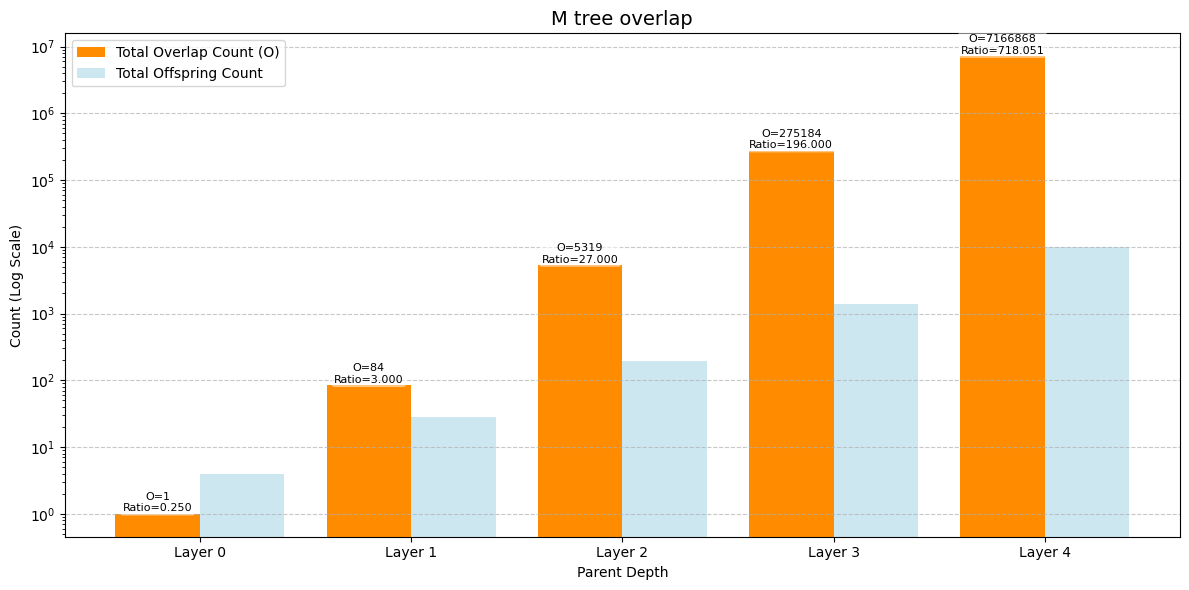

In [59]:
# 3. 准备绘图数据
layers = sorted(parsed_data.keys())
# 绘制总重叠次数
total_overlap_counts = [parsed_data[l]['total_overlap'] for l in layers]
total_nodes_counts = [parsed_data[l]['total'] for l in layers]
T_plot_values = np.clip(total_overlap_counts, a_min=1, a_max=None) # 用于绘图
layer_labels = [f'Layer {l}' for l in layers]
x = np.arange(len(layer_labels)) # x 轴标签位置
layer_labels = [f'Layer {l}' for l in layers]
x = np.arange(len(layer_labels))  # x 轴标签位置
bar_width = 0.4 # 柱子宽度

# 4. 绘制单图表 (无 Subplot)
plt.figure(figsize=(12, 6))
ax = plt.gca() # 获取当前的 Axes 对象

# --- 绘制总重叠次数 (T) ---
# 注意：使用 total_overlap_counts 对应您的 bars1
bars1 = ax.bar(x - bar_width/2, T_plot_values, bar_width, label='Total Overlap Count (O)', color='darkorange')

# --- 绘制总子节点数 (Total) 作为参考柱 ---
bars2 = ax.bar(x + bar_width/2, total_nodes_counts, bar_width, label='Total Offspring Count', color='lightblue', alpha=0.6)

# --- 设置 Y 轴为对数刻度 ---
ax.set_yscale('log')
ax.set_title('M tree overlap', fontsize=14)
ax.set_xlabel('Parent Depth')
ax.set_ylabel('Count (Log Scale)')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# 5. 添加数值标签和比值
for i, bar in enumerate(bars1):
    yval = bar.get_height()
    total_node_count = total_nodes_counts[i]
    
    # 避免除以零
    overlap_ratio = yval / total_node_count if total_node_count > 0 else 0.0
    
    # 显示总重叠次数和比值
    label_text = f'O={int(yval)}\nRatio={overlap_ratio:.3f}'
    
    # 在柱子上方放置标签
    # 由于是 log 刻度，需要稍微调整 y 位置
    ax.text(bar.get_x() + bar.get_width()/2, yval*1.02, label_text, 
            ha='center', va='bottom', fontsize=8, color='black', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round, pad=0.2')) 

plt.tight_layout()
plt.show()

In [3]:
try:
    # 1. 运行 C++ 程序并捕获输出
    # 1. 运行 C++ 程序并捕获输出
    executable = "../anchor_mapping"
    args = [
        "--max_node_capacity", "10",
        "--leaf_radius_threshold", "6",
        "--compactness_min_capacity", "8",
        "--compactness_radius_factor", "1.1"
    ]
    command = [executable] + args

    result = subprocess.run(
        command,  # 正确地传入分解后的列表
        capture_output=True,
        text=True,
        check=True
    )
    output = result.stdout
    
except FileNotFoundError:
    print(f"错误: 找不到可执行文件。请确保文件路径正确且已编译。")
except subprocess.CalledProcessError as e:
    print(f"错误: C++ 程序运行失败，退出码 {e.returncode}。")
    print("--- C++ 错误输出 ---")
    print(e.stderr)

# 2. 解析 C++ 输出中的数据
parsed_data = {} # 结构: {layer: {'total': N, 'multi_contained': M, 'total_overlap': T}}

# 正则表达式用于匹配新的输出格式
# 匹配 父层级: (N) | 子节点总数: (N) | 被多次覆盖枢轴数: (N) (...) | 总重叠次数: (N)
pattern = re.compile(
    r"父层级:\s+(\d+)\s+\|\s+子节点总数:\s+(\d+)\s+\|\s+被多次覆盖枢轴数:\s+(\d+)\s+.*?\s+\|\s+总重叠次数:\s+(\d+)"
)

for line in output.splitlines():
    match = pattern.search(line)
    if match:
        layer = int(match.group(1))
        total_nodes = int(match.group(2))
        multi_contained = int(match.group(3))
        total_overlap = int(match.group(4))
        
        parsed_data[layer] = {
            'total': total_nodes,
            'multi_contained': multi_contained,
            'total_overlap': total_overlap
        }

if not parsed_data:
    print("警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。")
    print("--- C++ 原始输出 ---")
    print(output)


警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。
--- C++ 原始输出 ---
fasta_path: /home/luting/nfs/luting_data/AnchorBasedMapping/ecoli/fasta/ecoli.fa
truncate_ref_len: 10000
anchor_len: 20
num_anchors: 100
num_queries: 100
maxDist: 3
use_all: true
start_idx: 0
end_idx: 0.2
last_random: 0
anchor radius: 3
seed: 42
--- M-Tree Config ---
min_node_capacity: 50
max_node_capacity: 10
leaf_radius_threshold: 6
compactness_min_capacity: 8
compactness_radius_factor: 1.1
auto generate queries: 0
Using reference (truncated) length = 10000
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node comp

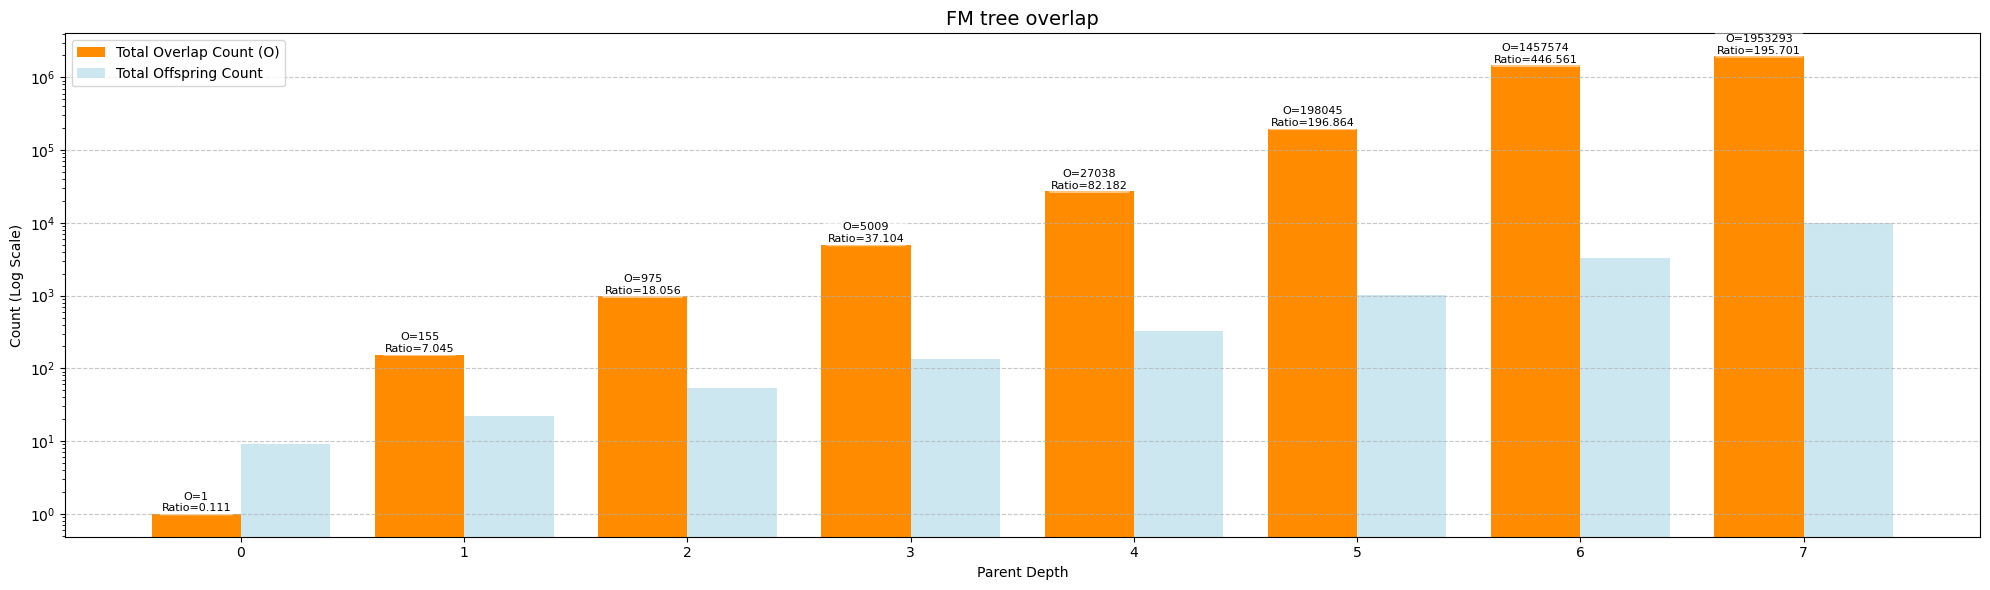

In [61]:
# 3. 准备绘图数据
layers = sorted(parsed_data.keys())
# 绘制总重叠次数
total_overlap_counts = [parsed_data[l]['total_overlap'] for l in layers]
total_nodes_counts = [parsed_data[l]['total'] for l in layers]
T_plot_values = np.clip(total_overlap_counts, a_min=1, a_max=None) # 用于绘图
layer_labels = [l for l in layers]
x = np.arange(len(layer_labels)) # x 轴标签位置
layer_labels = [l for l in layers]
x = np.arange(len(layer_labels))  # x 轴标签位置
bar_width = 0.4 # 柱子宽度

# 4. 绘制单图表 (无 Subplot)
plt.figure(figsize=(20, 6))
ax = plt.gca() # 获取当前的 Axes 对象

# --- 绘制总重叠次数 (T) ---
# 注意：使用 total_overlap_counts 对应您的 bars1
bars1 = ax.bar(x - bar_width/2, T_plot_values, bar_width, label='Total Overlap Count (O)', color='darkorange')

# --- 绘制总子节点数 (Total) 作为参考柱 ---
bars2 = ax.bar(x + bar_width/2, total_nodes_counts, bar_width, label='Total Offspring Count', color='lightblue', alpha=0.6)

# --- 设置 Y 轴为对数刻度 ---
ax.set_yscale('log')
ax.set_title('FM tree overlap', fontsize=14)
ax.set_xlabel('Parent Depth')
ax.set_ylabel('Count (Log Scale)')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# 5. 添加数值标签和比值
for i, bar in enumerate(bars1):
    yval = bar.get_height()
    total_node_count = total_nodes_counts[i]
    
    # 避免除以零
    overlap_ratio = yval / total_node_count if total_node_count > 0 else 0.0
    
    # 显示总重叠次数和比值
    label_text = f'O={int(yval)}\nRatio={overlap_ratio:.3f}'
    
    # 在柱子上方放置标签
    # 由于是 log 刻度，需要稍微调整 y 位置
    ax.text(bar.get_x() + bar.get_width()/2, yval*1.02, label_text, 
            ha='center', va='bottom', fontsize=8, color='black', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round, pad=0.2')) 

plt.tight_layout()
plt.show()

# Tree node access


--- Node Access Histogram Plotting ---
Collected 100 individual node access data points.
Saved node access histogram to ./fig/histogram_node_accesses_fmtree.png


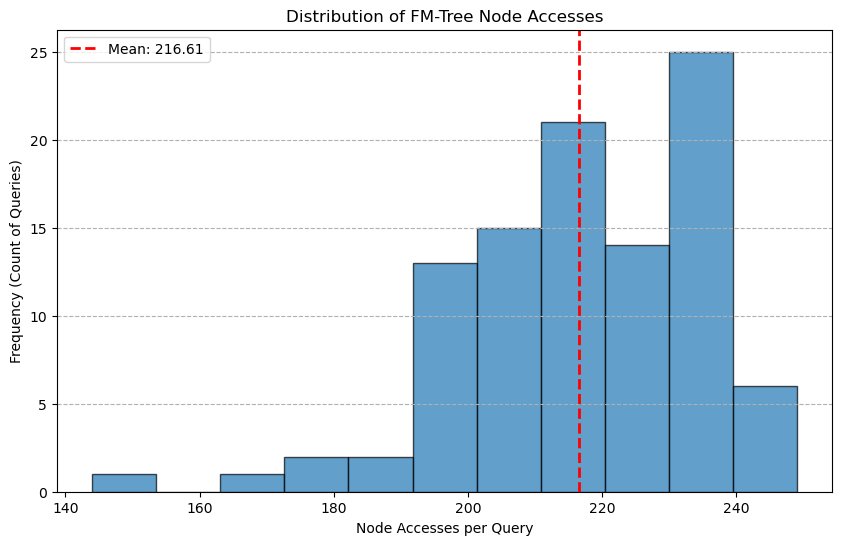

In [2]:
# --- 配置参数 ---
EXECUTABLE = "../anchor_mapping"

# 固定的测试参数 (只运行一次，不进行 sweep)
args = [
        "--min_node_capacity", "10",
        "--leaf_radius_threshold", "30",
        "--compactness_min_capacity", "5",
        "--compactness_radius_factor", "1",
        "--auto_gen", "true",
        "--method", "mtree"
    ]

# --- 运行和数据收集 ---

# 列表用于存储所有查询的单个节点访问次数
all_node_accesses = []

# 构造命令行
cmd = [EXECUTABLE] + args

# 执行程序
proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8')

if proc.returncode != 0:
    print(f"Error running command: {' '.join(cmd)}")
    print(f"STDERR:\n{proc.stderr}")
    exit(1)

output = proc.stdout

# 提取所有 "M-Tree search node accesses" 的值
access_pattern = r"M-Tree search node accesses: (\d+)"
accesses_this_run = re.findall(access_pattern, output)

# 将字符串转换为整数并存储
if accesses_this_run:
    all_node_accesses.extend([int(count) for count in accesses_this_run])
else:
    print("⚠️ Warning: No 'FM-Tree search node accesses' output found.")


# --- 结果可视化：绘制直方图 ---

print(f"\n--- Node Access Histogram Plotting ---")
total_data_points = len(all_node_accesses)
print(f"Collected {total_data_points} individual node access data points.")

if total_data_points == 0:
    print("Cannot plot histogram as no data was collected.")
else:
    # 确保输出目录存在
    os.makedirs("./fig", exist_ok=True)
    
    # 创建图窗 (figure)
    plt.figure(figsize=(10, 6))
    
    # 绘制直方图
    # 'bins'='auto' 让 Matplotlib 自动选择最佳的 bin 数量
    n, bins, patches = plt.hist(
        all_node_accesses, 
        bins='auto', 
        edgecolor='black', 
        alpha=0.7
    )
    

    # 设置标题和标签
    plt.title(f"Distribution of FM-Tree Node Accesses")
    plt.xlabel("Node Accesses per Query")
    plt.ylabel("Frequency (Count of Queries)")
    plt.grid(axis='y', linestyle='--')
    
    # 计算并显示平均值
    avg_accesses = sum(all_node_accesses) / total_data_points
    plt.axvline(avg_accesses, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {avg_accesses:.2f}')
    plt.legend()

    # 保存图像
    filename = f"./fig/histogram_node_accesses_fmtree.png"
    plt.savefig(filename)
    print(f"Saved node access histogram to {filename}")
    
    # 显示图像
    plt.show()


--- Node Access Histogram Plotting ---
Collected 100 individual node access data points.
Saved node access histogram to ./fig/histogram_node_accesses_mtree.png


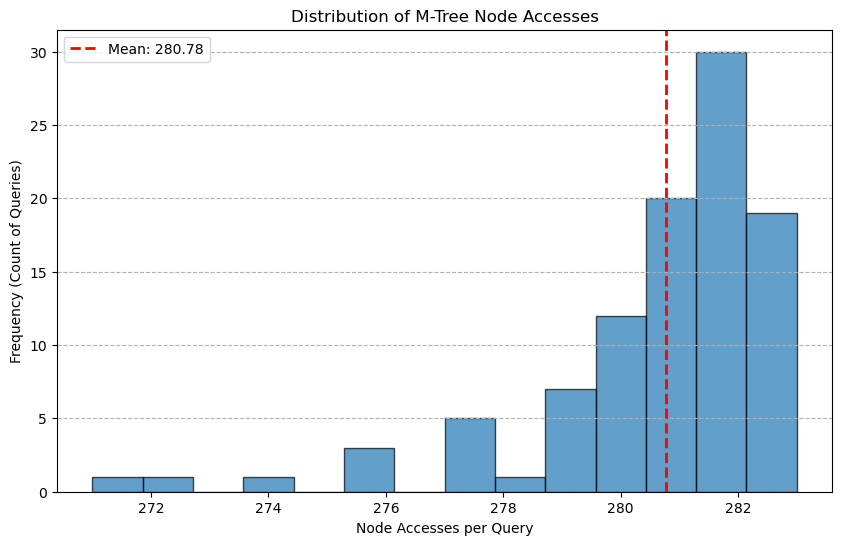

In [5]:
# --- 配置参数 ---
EXECUTABLE = "../anchor_mapping"

# 固定的测试参数 (只运行一次，不进行 sweep)
args = [
        "--min_node_capacity", "25",
        "--leaf_radius_threshold", "0",
        "--compactness_min_capacity", "1000",
        "--compactness_radius_factor", "1000",
        "--auto_gen", "true",
        "--method", "mtree"
    ]

# --- 运行和数据收集 ---

# 列表用于存储所有查询的单个节点访问次数
all_node_accesses = []

# 构造命令行
cmd = [EXECUTABLE] + args

# 执行程序
proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8')

if proc.returncode != 0:
    print(f"Error running command: {' '.join(cmd)}")
    print(f"STDERR:\n{proc.stderr}")
    exit(1)

output = proc.stdout

# 提取所有 "M-Tree search node accesses" 的值
access_pattern = r"M-Tree search node accesses: (\d+)"
accesses_this_run = re.findall(access_pattern, output)

# 将字符串转换为整数并存储
if accesses_this_run:
    all_node_accesses.extend([int(count) for count in accesses_this_run])
else:
    print("⚠️ Warning: No 'M-Tree search node accesses' output found.")


# --- 结果可视化：绘制直方图 ---

print(f"\n--- Node Access Histogram Plotting ---")
total_data_points = len(all_node_accesses)
print(f"Collected {total_data_points} individual node access data points.")

if total_data_points == 0:
    print("Cannot plot histogram as no data was collected.")
else:
    # 确保输出目录存在
    os.makedirs("./fig", exist_ok=True)
    
    # 创建图窗 (figure)
    plt.figure(figsize=(10, 6))
    
    # 绘制直方图
    # 'bins'='auto' 让 Matplotlib 自动选择最佳的 bin 数量
    n, bins, patches = plt.hist(
        all_node_accesses, 
        bins='auto', 
        edgecolor='black', 
        alpha=0.7
    )
    
    # 设置标题和标签
    plt.title(f"Distribution of M-Tree Node Accesses")
    plt.xlabel("Node Accesses per Query")
    plt.ylabel("Frequency (Count of Queries)")
    plt.grid(axis='y', linestyle='--')
    
    # 计算并显示平均值
    avg_accesses = sum(all_node_accesses) / total_data_points
    plt.axvline(avg_accesses, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {avg_accesses:.2f}')
    plt.legend()

    # 保存图像
    filename = f"./fig/histogram_node_accesses_mtree.png"
    plt.savefig(filename)
    print(f"Saved node access histogram to {filename}")
    
    # 显示图像
    plt.show()